### Market Impact Calculations

In this notebook, we implement a theoretical system that aims to shed some light on one of the stochastic constituents of Transaction Cost Analysis (TCA) that of the market impact. We will start by presenting some of the theory behind TCA and then move on to the implementation and analysis of the market impact calculations.

With regards to the dataset, we will be using LSEG D&A libraries to ingest historical pricing data and use used to calculate the important components of market impact.

### Supply & Demand constituent

Let’s assume an initial stock price of  initial_price GBP and that there is no drift or market memory. Let's also assume that buyers are always willing to cross the spread and the spread remains constant to bp_impact. All things remain equal, the market should be able to absorb the supply and demand instantaneous shift. We assume an exponential decay of impact exponential_decay(x0, t, gamma=1) and we run the calculations for n ticks.

### Import libraries and open the data session

Let's start by importing the necessary libraries and opening a data session.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import refinitiv.data as rd

from refinitiv.data.content import historical_pricing
from refinitiv.data.content.historical_pricing import Intervals
from refinitiv.data.content.historical_pricing import MarketSession

In [2]:
rd.open_session()

<refinitiv.data.session.Definition object at 0x7f4b64985b80 {name='codebook'}>

### Get our data - one Line API call

Here we use our get_data function to return hourly OHLCV for VOD.L for a single day’s worth of trading. Note the dataframe is already indexed on timestamp.

In [4]:
response = historical_pricing.summaries.Definition(
    universe = "VOD.L", 
    interval = Intervals.HOURLY,
    start='01-10-2024',
    end='01-11-2024',
    sessions = [
        MarketSession.NORMAL
    ],
    fields = ["OPEN_PRC", "HIGH_1", "LOW_1", "TRDPRC_1", "ACVOL_UNS"]
).get_data()
df = response.data.df
df.columns = ["open", "high", "low", "close", "volume"]
df

,open,high,low,close,volume
Timestamp,,,,,
2024-01-10 08:00:00,69.87,70.19,69.63,70.1,1766031
2024-01-10 09:00:00,70.11,70.19,69.97,69.9773,1112789
2024-01-10 10:00:00,70.0,70.0,69.57,69.65,1489558
2024-01-10 11:00:00,69.64,69.64,69.51,69.5257,616290
2024-01-10 12:00:00,69.54,69.73,69.53,69.58,602317
2024-01-10 13:00:00,69.57,69.71,69.57,69.59,1536938
2024-01-10 14:00:00,69.61,69.71,69.37,69.39,2987149
2024-01-10 15:00:00,69.36,69.461,68.818,68.87,4851765
2024-01-10 16:00:00,68.88,69.032,68.62,68.62,22890282


### Calculating liquidity

For our market impact and impact absorption model we will need a surrogate of liquidity. This will allow as to calculate how fast the market landscape is able to respond to an order execution to mitigate its market impact. 

In [5]:
def liquidity_calc(x):
    return (x['volume'] * x['close']) / (x['high'] - x['low'])


df['liquidity'] = df.apply(liquidity_calc, axis=1)
df

,open,high,low,close,volume,liquidity
Timestamp,,,,,,
2024-01-10 08:00:00,69.87,70.19,69.63,70.1,1766031,2.210692e+08
2024-01-10 09:00:00,70.11,70.19,69.97,69.9773,1112789,3.539544e+08
2024-01-10 10:00:00,70.0,70.0,69.57,69.65,1489558,2.412738e+08
2024-01-10 11:00:00,69.64,69.64,69.51,69.5257,616290,3.296000e+08
2024-01-10 12:00:00,69.54,69.73,69.53,69.58,602317,2.095461e+08
2024-01-10 13:00:00,69.57,69.71,69.57,69.59,1536938,7.639680e+08
2024-01-10 14:00:00,69.61,69.71,69.37,69.39,2987149,6.096420e+08
2024-01-10 15:00:00,69.36,69.461,68.818,68.87,4851765,5.196595e+08
2024-01-10 16:00:00,68.88,69.032,68.62,68.62,22890282,3.812454e+09


Next, we will need to apply a transformation function that will correctly scale liquidity so that it can be used from our theoretical model, we use the sigmoid function for that purpose and apply it to our dataset: 

In [7]:
def sigmoid_liquidity(x):
    return 1/(1+np.exp(-x['norm_liquidity']))

df['sigmoid_liquidity'] = df.apply(sigmoid_liquidity, axis=1)
df

,open,high,low,close,volume,liquidity,norm_liquidity,sigmoid_liquidity
Timestamp,,,,,,,,
2024-01-10 08:00:00,69.87,70.19,69.63,70.1,1766031,2.210692e+08,0.003198,0.500800
2024-01-10 09:00:00,70.11,70.19,69.97,69.9773,1112789,3.539544e+08,0.040081,0.510019
2024-01-10 10:00:00,70.0,70.0,69.57,69.65,1489558,2.412738e+08,0.008806,0.502202
2024-01-10 11:00:00,69.64,69.64,69.51,69.5257,616290,3.296000e+08,0.033321,0.508330
2024-01-10 12:00:00,69.54,69.73,69.53,69.58,602317,2.095461e+08,0.000000,0.500000
2024-01-10 13:00:00,69.57,69.71,69.57,69.59,1536938,7.639680e+08,0.153882,0.538395
2024-01-10 14:00:00,69.61,69.71,69.37,69.39,2987149,6.096420e+08,0.111048,0.527734
2024-01-10 15:00:00,69.36,69.461,68.818,68.87,4851765,5.196595e+08,0.086073,0.521505
2024-01-10 16:00:00,68.88,69.032,68.62,68.62,22890282,3.812454e+09,1.000000,0.731059


Let’s now plot sigmoid liquidity to examine its behaviour:

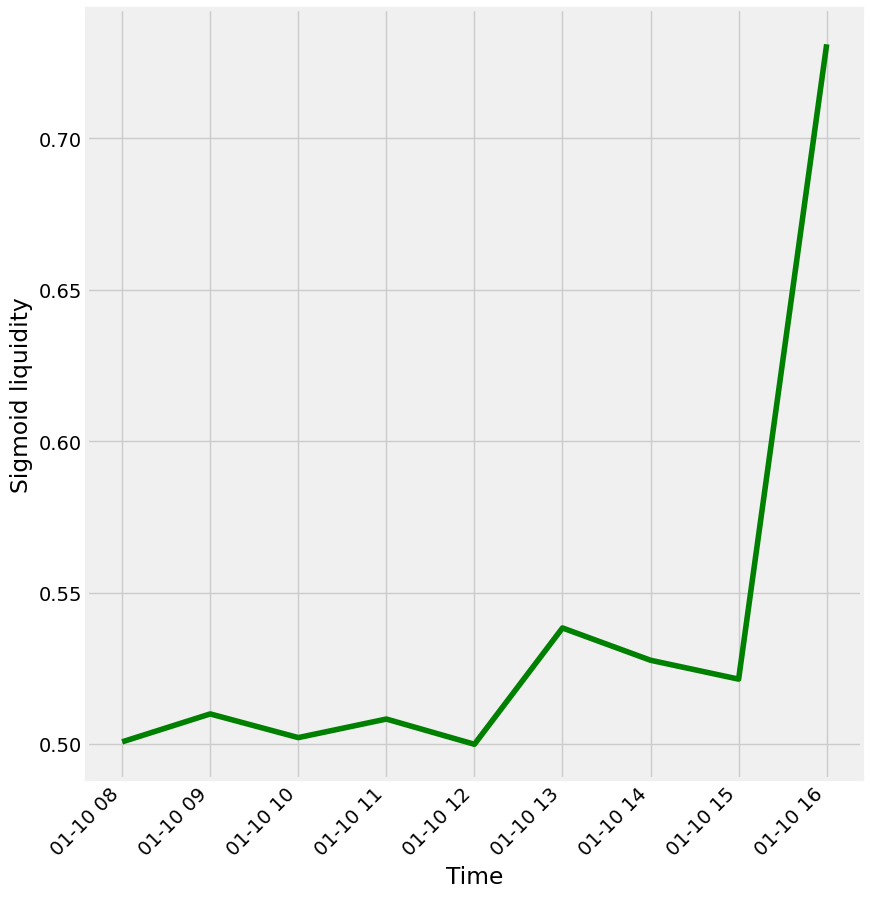

In [8]:
fig = plt.figure(figsize=(10,10))
plt.style.use('fivethirtyeight')
plt.plot(df['sigmoid_liquidity'], color='green')
plt.xlabel("Time")
plt.ylabel("Sigmoid liquidity")
plt.xticks(rotation=45, ha="right")
plt.show()

We can now calculate the rate at which the market is able to absorb market impact for every one-hour period, using the following assumption of exponential decay:

In [9]:
bp_impact = 10
ticks = 20
initial_price = 1

def exponential_decay(x0, t, gamma=1):
    return x0 * np.exp(-gamma * t)


market = []
for ix, row in df.iterrows():
    mi = initial_price * bp_impact / 100 / 100
    mi_price = initial_price + mi
    market_hour = [mi_price] * ticks
    for t in range(1, ticks):
        market_hour[t] = initial_price + exponential_decay(mi, t, row['sigmoid_liquidity'])
    market.append(market_hour)

The following plot shows how quickly the market, depending on hourly liquidity, can absorb the 10bp impact. We can see the variation in behaviour with hours of low liquidity absorbing impact at a slower rate.

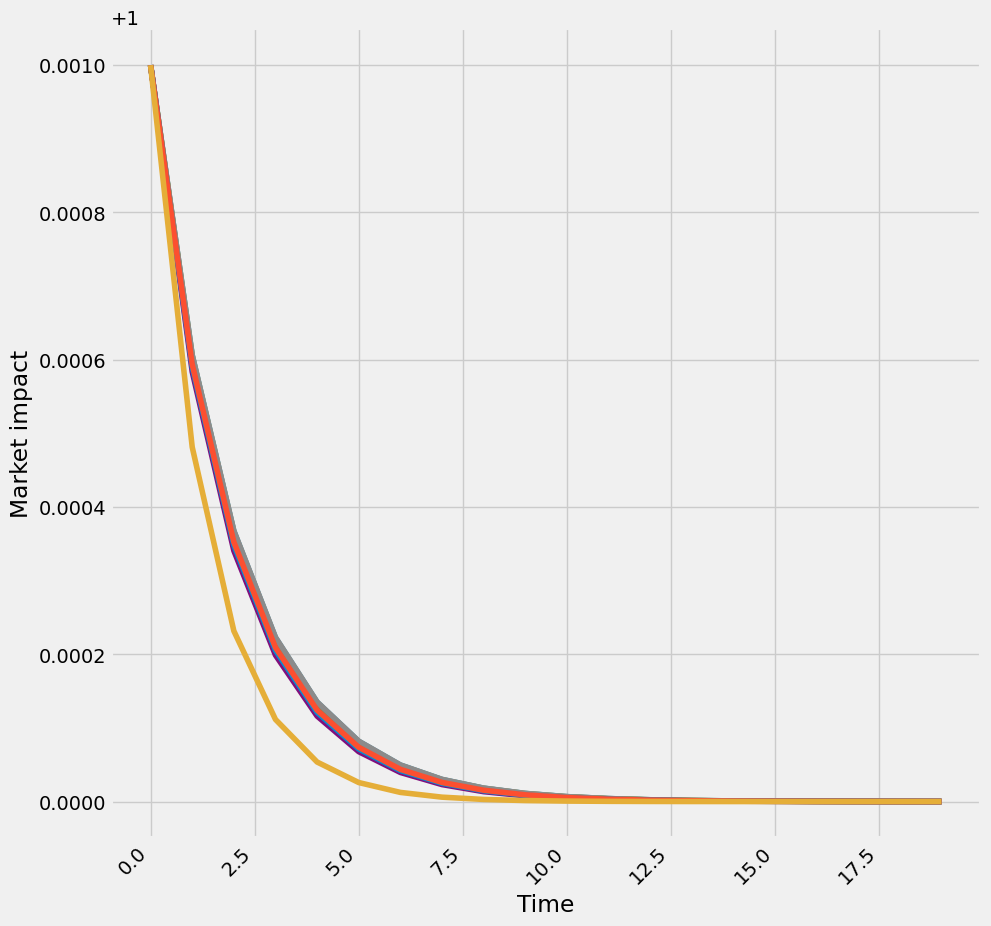

In [10]:
fig = plt.figure(figsize=(10,10))
plt.style.use('fivethirtyeight')
for hour in market:
    plt.plot(hour)
plt.xlabel("Time")
plt.ylabel("Market impact")
plt.xticks(rotation=45, ha="right")
plt.show()

Let's now write a function that will simulate a scenario where multiple participants execute a trading schedule within a day with a probability of crossing the spread of trade_probability. We simulate a trading flow of n ticks and assume that each trade will cause an impact in the order book of min_bp to max_bp basis points.

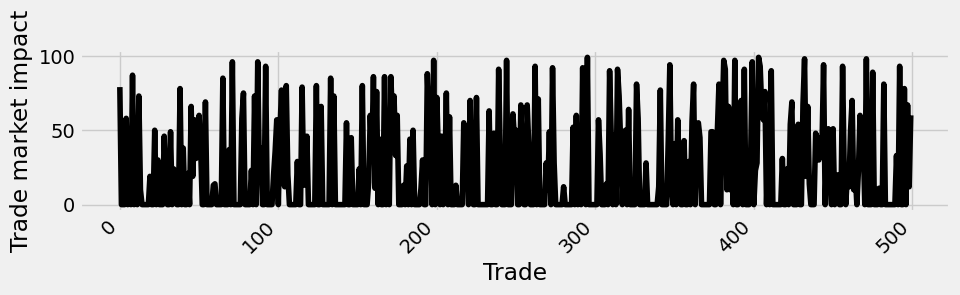

In [12]:
min_bp = 10
max_bp = 100

ticks = 500
ticks_per_hour = int(ticks / len(df))
trade_probability = 0.45

def candle_trading_flow(ticks, trade_probability, min_bp, max_bp):
    trade_flow = (np.random.rand(ticks) > 1 - trade_probability).astype(int)

    impact_flow = []
    for trade in trade_flow:
        trade *= np.random.randint(min_bp, max_bp) 
        impact_flow.append(trade)
        
    return trade_flow, impact_flow
    
    
trade_flow, impact_flow = candle_trading_flow(ticks, trade_probability, min_bp, max_bp)

fig = plt.figure(figsize=(10,2))
plt.style.use('fivethirtyeight')
plt.plot(impact_flow , color='black')
plt.xlabel("Trade")
plt.ylabel("Trade market impact")
plt.xticks(rotation=45, ha="right")
plt.show()

Next, we apply the theoretical model within each day to reveal impact results to price.

In [13]:
initial_price = 1
trade_flow_length = len(trade_flow)
market_price = [initial_price] * trade_flow_length

trade_impact = {}

hour_candle = 0 
for t in range(trade_flow_length):
    trade_impact[t] = []
    
for t1 in range(trade_flow_length):
    if ticks_per_hour % (t1+1) == 0:
        hour_candle += 1
    for t in range(t1):
        trade_impact[t1].append(0)
    # print(f"{hour_candle}:liquidity gamma:{df1.iloc[hour_candle]['sigmoid_liquidity']}")    
    for t2 in range(trade_flow_length - t1):
        if trade_flow[t1] == 1:
            mi = initial_price * impact_flow[t1] / 100 / 100
            market_price[t1 + t2] = (market_price[t1 + t2] + exponential_decay(mi, t2, df.iloc[hour_candle]['sigmoid_liquidity']))
            trade_impact[t1].append(exponential_decay(mi, t2, 0.05))

We can now see how this trading schedule affects the market price with hourly periods of higher liquidity being able to absorb trading flow impact resulting in price returning to its initial value. Another interesting phenomenon to observe is that around the 400th tick of the trading flow and as activity is lower it is much easier for the market to absorb market impact.

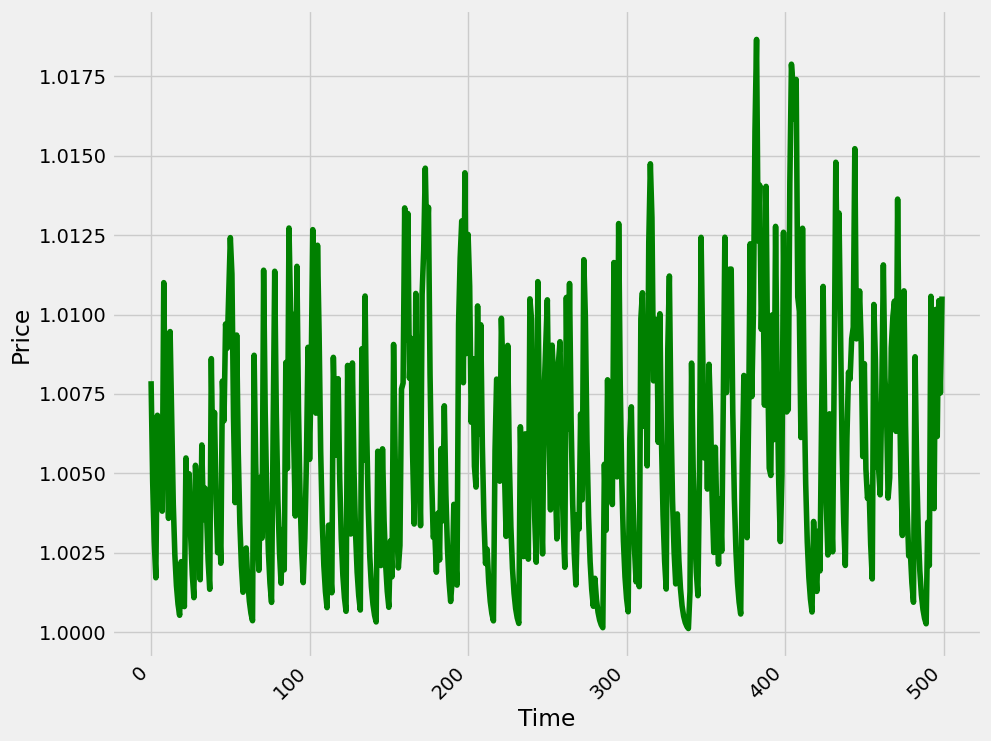

In [14]:
fig = plt.figure(figsize=(10,8))
plt.style.use('fivethirtyeight')
plt.plot(market_price, color='green')

plt.xlabel("Time")
plt.ylabel("Price")
plt.xticks(rotation=45, ha="right")
plt.show()

### Conclusions

In this article we explore a theoretical market impact absorption model to shed some light on market price dynamics. We ingest a day’s worth of hourly data using LSEG D&A data libraries and we calculate hourly liquidity. Using a sigmoid transformation, we bound liquidity and generate a gamma metric which we then use to calculate hourly market impact absorption rates. We can then simulate and observe market price dynamics during the day and better understand market impact and how trade flow aggressiveness can affect our executions’ transaction costs.